In [1]:
from InSitu14CO import Propagator
import numpy as np
import matplotlib.pyplot as plt
import crflux.models as pm
import matplotlib.ticker as ticker
import matplotlib as mpl
import Functions_14CO as F

from IPython.display import display

from tqdm import tqdm

import pandas as pd

from scipy import stats

from scipy.ndimage import gaussian_filter

import pyunfold as pu

from scipy.io import loadmat
from scipy.interpolate import interp1d

In [2]:
axes_style = { 'grid'      : 'True',
               'labelsize' : '14',
               'labelpad'  : '8.0'
             }
grid_style = { 'alpha'     : '0.75',
               'linestyle' : ':' }
font_style = { 'size'      : '12' }

mpl.rc('font', **font_style)
mpl.rc('axes', **axes_style)
mpl.rc('grid', **grid_style)

In [3]:
def T(A):
    return np.swapaxes(A, -2, -1)

## Dome C Site Data & Production Rates

We set up a Propagator for the Dome C site and load pre-calculated Production Rates

In [4]:
site = 'DomeC'
Prop = Propagator()
density_model = ('MSIS00', ('SouthPole', 'January'))

df_Pfast = pd.read_csv('Production Rates/P_fast_DomeC_3233m.csv')
df_Pneg = pd.read_csv('Production Rates/P_neg_DomeC_3233m.csv')
P_14C = np.swapaxes([df_Pfast.T, df_Pneg.T], 0, 1)
model_names = list(df_Pfast.columns)

# The only production model being used is Heisinger
#i = model_names.index('Heisinger')
#prod_cut = np.arange(len(P_14C))[i:i+1]

#Prop.Phi['prod']=P_14C[prod_cut]
#C_flow_response = F.flow_14C_response(Prop)[0]
#C_response = C_flow_response @ Prop.S_mat[Prop.i_start:]

z_samp = Prop.z_samp

## Setting Up Time Bins

We separate our time bins into two sections:

Our high-sensitivity region ($\sim$7 kya to present) which affects both Dome C and Taylor Glacier $^{14}$CO levels, and where we use a bin-width of 1 year.

Our low-sensitivity region ($\sim$50 kya to $\sim$7 kya) which only affects the equilibirum level of $^{14}$CO at Taylor Glacier before the start of integration, and where we use a bin-width of 100 years.

In [5]:
# Dome C Time Bins
dt_DC = Prop.dt_int[0]
t_bins_DC = Prop.t_int_bins-Prop.t_int_bins[-1]
t_DC = Prop.t_int-Prop.t_int_bins[-1]
Period_DC = t_bins_DC[-1]-t_bins_DC[0]

# Taylor Glacier Time Bins
dt_TG_short = 1
dt_TG_long = 100
Period_TG_short = Period_DC
Period_TG = 50000

t_bins_TG_short = -np.flip(np.arange(0, Period_TG_short+dt_TG_short, dt_TG_short)) # time integration steps
t_TG_short = (t_bins_TG_short[:-1]+t_bins_TG_short[1:])/2
t_bins_TG_long = -np.flip(np.arange(-t_bins_TG_short[0], Period_TG+dt_TG_long, dt_TG_long))
t_TG_long = (t_bins_TG_long[:-1]+t_bins_TG_long[1:])/2

t_bins_TG = np.concatenate((t_bins_TG_long[:-1], t_bins_TG_short))
t_TG = (t_bins_TG[:-1]+t_bins_TG[1:])/2
dt_TG = np.diff(t_bins_TG)

# Full Model Time Bins
Period = Period_TG
t_bins = t_bins_TG
t = t_TG
dt = dt_TG

t_scale = t/Period_DC # time scaled from -1 to 0, with 0=present

f_interp_to_DC = ((t_bins[1:].reshape((-1,1))-t_bins_DC[:-1].reshape((1,-1))).clip(0,dt_DC) - (t_bins[:-1].reshape((-1,1))-t_bins_DC[:-1].reshape((1,-1))).clip(0,dt_DC))/dt_DC
f_interp_to_TG = ((t_bins[1:].reshape((-1,1))-t_bins_TG[:-1].reshape((1,-1))).clip(0,dt_TG) - (t_bins[:-1].reshape((-1,1))-t_bins_TG[:-1].reshape((1,-1))).clip(0,dt_TG))/dt_TG

## Taylor Glacier Site Data & Production Rates

We set up a Propagator for the Taylor Glacier site and load pre-calculated Production Rates

In [6]:
# sets the conditions for the study at Taylor Glacier by Dyonisius et al. (https://tc.copernicus.org/articles/17/843/2023/)
rho_ice = 0.92
h_bins = h_bins = np.arange(0, 1001, 1)
Prop_TG = Propagator(pressure=9.248658001389917e+04, # (Pa) pressure used in Taylor Glacier analysis "from LSD ERA reanalysis"
                  elev=526, # (m) elevation listed in Figure 1 caption of Taylor Glacier study (need to confirm)
                  z_grid=h_bins/rho_ice,
                  h_grid=h_bins,
                  rho_ice=rho_ice,
                  z_close=0,
                 ) # (g/cm^3) density used in Taylor Glacier analysis

df_Pfast_TG = pd.read_csv('Production Rates/P_fast_TaylorGlacier_526m.csv')
df_Pneg_TG = pd.read_csv('Production Rates/P_neg_TaylorGlacier_526m.csv')
P_14C_TG = np.swapaxes([df_Pfast_TG.T, df_Pneg_TG.T], 0, 1)
model_names_TG = list(df_Pfast_TG.columns)

# The only production model being used is Heisinger
#i = model_names_TG.index('Heisinger')
#prod_cut_TG = np.arange(len(P_14C_TG))[i:i+1]

#flow = 'sample'
#flowpath = loadmat('matlab/MC_14CO_mod/flowpath_{}.mat'.format(flow))
#age = flowpath['age'][0]

#Prop_TG.Phi['prod']=P_14C_TG[prod_cut_TG]
#C_response_TG, C_init_TG = F.Taylor_flow_response(Prop_TG, flow, t_bins=t_bins_TG)
#C_response_TG = C_response_TG[0,0]
#C_init_TG = C_init_TG[0,0]

TG_data = loadmat('matlab/MC_14CO_mod/TG_data_14CO.mat')
CO_exp_TG_data = TG_data['CO_molec'][3:,0]
CO_err_TG_data = TG_data['CO_molec_err'][3:,0]/2.
z_samp_TG = TG_data['sample_depth_CO'][3:,0]

## Propagating Uncertainties in Production

Once we have a suitable contraint on the production rates (ignoring scaling factors), we can calculate a baesian likelihood $L$ by propagating the covariance in the production rates and integrating over the remaining uncertainties with either a grid or MCMC (or some combination of both).

$$\vec{P}_{\mu_f,\mu-,n^0}(h,\alpha) = \sum_E dE\,(N\hat{\sigma}_{190}(\frac{\hat{E}}{190})^\alpha\sum_{\mu^\pm}, \hat{f}_{\text{tot}}\hat{\frac{d}{dh}} \hat{\delta}_{\mu^-}, N\hat{\sigma}_{n^0}\hat{\delta}_{n^0})\, \Phi_{\mu^\pm, n^0}(E,h) = \hat{O}_{msEhh'}(\alpha) \vec{\Phi}_{sEh'}$$

$\vec{\Phi}(E,h)$ - underground energy spectra

$\hat{O}(\alpha)$ - production operator

$\vec{P}_m (h,\alpha)$ - unscaled production rates

$$\Sigma_P(\alpha) = \int \Delta \vec{P}\Delta \vec{P}^Tp(\vec{P}|\alpha) d\vec{P}$$

$\Sigma_p(\alpha)$ - unscaled production rate covariances

$$\vec{f}_{\mu_f, \mu-, n^0} = (\Omega_{CO}\frac{\sigma_{190}}{\hat{\sigma}_{190}}, \Omega_{CO}\frac{f_{\text{tot}}}{\hat{f}_{\text{tot}}}, \Omega_{CO}\frac{P_{n^0}(0)}{\hat{P}_{n^0}(0)})$$

$\Omega_{CO}$ - $^{14}$CO/$^{14}$C ratio

$\vec{f}$ - production rate scale factors

$$\hat{c}_z(\vec{\phi}) = \frac{1}{h_{z+1}-h_z}\int_{h_z}^{h_{z+1}}\int_{t'(h)}^0 \vec{f}\cdot\vec{P}(h'(h,t))\phi(t)e^{\lambda t}\,dt\,dh = \hat{Z}_{zht}\vec{f}_{m}\vec{P}_{mh}\vec{\phi}_t$$

$h_z$ - sample depth bins

$h'(h,t)$ - depth at time $t$ of ice parcel w/ present depth $h$

$t'(h)$ - time when ice parcel at depth $h$ began accumulating $^{14}$CO

$\vec{\phi}$ - CR flux history

$\hat{Z}$ - accumulation operator

$\hat{c}_z(\vec{\phi})$ - predicted $^{14}$CO concentrations

$$\Sigma_{\hat{c}}(\vec{\phi},\alpha, \vec{f}, \hat{Z})_{zz'} = (\hat{Z}\vec{\phi})_{zh}(\vec{f}\Sigma_P(\alpha) \vec{f}^T)_{hh'} (\hat{Z}\vec{\phi})^T_{z'h'}$$

$\Sigma_{\hat{c}}$ - covariance in predicted $^{14}$CO from underground spectrum uncertainties

$$L(\vec{\phi}|\vec{c}) = \iiint \frac{e^{-(\vec{c}-\hat{c})^T(\Sigma+\Sigma_{\hat{c}})^{-1}(\vec{c}-\hat{c})/2}}{\sqrt{|2\pi(\Sigma+\Sigma_{\hat{c}})|}} p(\alpha)p(\vec{f})p(\hat{Z})\,d\alpha\, d\vec{f}\, d\hat{Z}$$

$\vec{c}$ - measured $^{14}$CO concentrations

$\Sigma$ - experimental uncertainties

The next step is to calculate $L(\vec{\phi}_0|\vec{\phi}_0)$ for ~1 million random throws and fit the distribution to get a function for the p-value $p( \leq L|\text{null})$, so we can convert $L$ into standard deviations $\sigma$.

Since experimental error is normally distributed by $\Sigma$, it should be easy to calculate the distribution of $L$ under specific independent variables $\alpha, \vec{f}, \hat{Z}$.  So all we need to randomize over are these variables, and we can then combine their $L$ distributions to get a more accurate (and easier to calculate) conversion to the p-value!

I think we can incorporate a gaussian uncertainty in $\alpha$ into the unscaled production rate uncertainty, so we'd only need to integrate over $\vec{f}$ and $\hat{Z}$

More realistically, we should have two gaussian uncertainties on $\alpha$, which we switch between.  Either $\alpha = 0.75 \pm 0.08$ (Literature citations) or $\alpha = 0.093 \pm 0.07$ (Heisinger measurement)

$$dP_{\text{fast}} = \frac{\partial P}{\partial \vec{\Phi}}\cdot d\vec{\Phi} + \frac{\partial P}{\partial \alpha}d\alpha = N\sigma \sum dE (\frac{E}{190})^\alpha d\vec{\Phi} + N\sigma \sum dE \vec{\Phi} \frac{\partial}{\partial \alpha} (\frac{E}{190})^\alpha = \hat{O}[d\vec{\Phi} + \ln(\frac{\hat{E}}{190}) \vec{\Phi}\, d\alpha]$$

$$\Sigma_P' = dP dP^T = O (d\Phi + \ln(\frac{\hat{E}}{190}) \vec{\Phi}\, d\alpha)(d\Phi + \ln(\frac{\hat{E}}{190}) \vec{\Phi}\, d\alpha)^T O^T = \Sigma_P + O (d\Phi (\ln(\frac{\hat{E}}{190}) \vec{\Phi})^Td\alpha + (\ln(\frac{\hat{E}}{190}) \vec{\Phi})d\Phi^Td\alpha + (\ln(\frac{\hat{E}}{190}) \vec{\Phi})(\ln(\frac{\hat{E}}{190}) \vec{\Phi})^T d\alpha^2) O^T$$

In [8]:
alpha = np.array([0.75, 0.93])
dalpha = np.array([0.08, 0.07])

alphas = np.arange(0.63,1.01,0.01)

In [9]:
model_names

['JN-fit_H-ice_alpha=0.63',
 'daemonflux_H-ice_alpha=0.63',
 "GlobalSplineFitBeta_MCEq_atm-SIBYLL23CPP-('MSIS00', ('SouthPole', 'January'))_H-ice_alpha=0.63",
 "HillasGaisser2012 H3a_MCEq_atm-SIBYLL23CPP-('MSIS00', ('SouthPole', 'January'))_H-ice_alpha=0.63",
 "HillasGaisser2012 H4a_MCEq_atm-SIBYLL23CPP-('MSIS00', ('SouthPole', 'January'))_H-ice_alpha=0.63",
 "PolyGonato_MCEq_atm-SIBYLL23CPP-('MSIS00', ('SouthPole', 'January'))_H-ice_alpha=0.63",
 "GaisserStanevTilav 3-gen_MCEq_atm-SIBYLL23CPP-('MSIS00', ('SouthPole', 'January'))_H-ice_alpha=0.63",
 "GaisserStanevTilav 4-gen_MCEq_atm-SIBYLL23CPP-('MSIS00', ('SouthPole', 'January'))_H-ice_alpha=0.63",
 "CombinedGHandHG H3a_MCEq_atm-SIBYLL23CPP-('MSIS00', ('SouthPole', 'January'))_H-ice_alpha=0.63",
 "ZatsepinSokolskaya pamela_MCEq_atm-SIBYLL23CPP-('MSIS00', ('SouthPole', 'January'))_H-ice_alpha=0.63",
 "ZatsepinSokolskaya default_MCEq_atm-SIBYLL23CPP-('MSIS00', ('SouthPole', 'January'))_H-ice_alpha=0.63",
 "GaisserHonda_MCEq_atm-SIBYLL2

In [10]:
(len(model_names)-1)//len(alphas)

1596

In [11]:
models_MCEq = np.reshape(model_names[:-1], (len(alphas),6,-1))[:,:,2:].reshape((len(alphas),6,2,11,-1))
#axis0 - alpha
#axis1 - Underice Propagation Model
#axis2 - Month (Atmospheric Profile)
#axis3 - Interaction Model
#axis4 - Primary Model

In [12]:
models_atmFit = np.reshape(model_names[:-1], (len(alphas),6,-1))[:,:,:2]
#axis0 - alpha
#axis1 - Underice Propagation Model
#axis2 - Atmospheric Muon Flux Fit

In [13]:
P_14C_MCEq = P_14C[:-1].reshape((len(alphas),6,-1,*P_14C.shape[1:]))[:,:,2:].reshape((len(alphas),6,2,11,-1,*P_14C.shape[1:]))
#axis0 - alpha
#axis1 - Underice Propagation Model
#axis2 - Month (Atmospheric Profile)
#axis3 - Interaction Model
#axis4 - Primary Model
#axis5 - Production Mode
#axis6 - Depth
P_14C_MCEq.shape

(38, 6, 2, 11, 12, 2, 255)

In [14]:
P_14C_atmFit = P_14C[:-1].reshape((len(alphas),6,-1,*P_14C.shape[1:]))[:,:,:2]
#axis0 - alpha
#axis1 - Underice Propagation Model
#axis2 - Atmospheric Muon Flux Fit
#axis5 - Production Mode
#axis6 - Depth
P_14C_atmFit.shape

(38, 6, 2, 2, 255)

In [22]:
P_avg = np.average(P_14C, axis=0)
#dP_14C = (P_14C-P_avg).reshape((len(P_14C),-1))
#P_cov = np.moveaxis(((dP_14C.T @ dP_14C)/len(P_14C)).reshape((*P_14C.T.shape[:-1], *P_14C.shape[1:])), 0, -2)
P_cov = np.cov(P_14C.reshape(len(P_14C),-1), rowvar=False).reshape(*P_14C.shape[1:],*P_14C.shape[1:]).swapaxes(1,2)

In [23]:
np.shape(P_cov)

(2, 2, 255, 255)

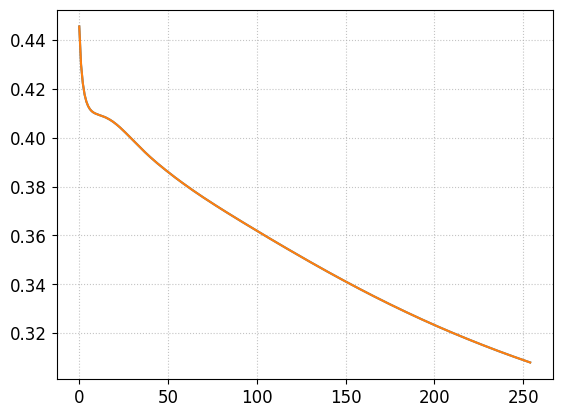

In [31]:
plt.plot(np.sqrt(np.diag(P_cov[0,0]))/P_avg[0])
plt.plot(np.std(P_14C, axis=0)[0]/P_avg[0])

In [32]:
P_cov.shape

(2, 2, 255, 255)

In [130]:
alphas[12]

np.float64(0.7500000000000001)

In [38]:
P_cov.shape

(2, 2, 255, 255)

In [142]:
models_MCEq[0,:,0,0,0]

array(["GlobalSplineFitBeta_MCEq_atm-SIBYLL23CPP-('MSIS00', ('SouthPole', 'January'))_H-ice_alpha=0.63",
       "GlobalSplineFitBeta_MCEq_atm-SIBYLL23CPP-('MSIS00', ('SouthPole', 'January'))_GS-ice_alpha=0.63",
       "GlobalSplineFitBeta_MCEq_atm-SIBYLL23CPP-('MSIS00', ('SouthPole', 'January'))_MCEq_mu_ice-None-False_alpha=0.63",
       "GlobalSplineFitBeta_MCEq_atm-SIBYLL23CPP-('MSIS00', ('SouthPole', 'January'))_MCEq_mu_ice-None-True_alpha=0.63",
       "GlobalSplineFitBeta_MCEq_atm-SIBYLL23CPP-('MSIS00', ('SouthPole', 'January'))_MCEq_mu_ice-Heisinger-False_alpha=0.63",
       "GlobalSplineFitBeta_MCEq_atm-SIBYLL23CPP-('MSIS00', ('SouthPole', 'January'))_MCEq_mu_ice-Heisinger-True_alpha=0.63"],
      dtype='<U124')

In [43]:
def prod_plot(P_cut):
    P_cut_avg = np.mean(P_cut, axis=0)
    P_cut_cov = np.cov(P_cut.reshape(len(P_cut),-1), rowvar=False).reshape(*P_cut.shape[1:],*P_cut.shape[1:]).swapaxes(1,2)
    P_cut_std = np.sqrt([np.diag(P_cut_cov[0,0]), np.diag(P_cut_cov[1,1])])
    #plt.fill_between(Prop.z, P_avg[0]-np.sqrt(np.diag(P_cov[0,0])), P_avg[0]+np.sqrt(np.diag(P_cov[0,0])))
    #for i,p in enumerate(P_14C):
    fig, ((ax1, ax2), (ax3,ax4)) = plt.subplots(2,2, figsize=(12,8), tight_layout=True, sharex=True, sharey='row', height_ratios=[2,1])
    ax1.plot(Prop.z, P_cut.T[:,0], c='grey', alpha=len(P_cut)**(-.6))
    ax1.fill_between(Prop.z, P_cut_avg[0]-2*P_cut_std[0], P_cut_avg[0]+2*P_cut_std[0], alpha = 0.2, color='m', zorder=10)
    ax1.plot(Prop.z, P_cut_avg[0], c='m', ls='--', label=r'Avg. w/ 2$\sigma$', zorder=11)
    ax1.plot(Prop.z, P_14C[-1,0], ls='--', c='k', label='Heisinger')
    ax1.set(
        yscale='log',
        #ylim = (2e-4,2e1),
        ylabel=r'$^{14}$C Production Rate [atoms /g /yr]',
        title = r'Fast Muon Interactions'
    )
    ax1.legend(loc='upper right')
    #plt.title(r'Fast Muons $\alpha$={:.2f}'.format(alphas[i]))

    ax2.plot(Prop.z, P_cut.T[:,1], c='grey', alpha=len(P_cut)**(-.6))
    ax2.fill_between(Prop.z, P_cut_avg[1]-2*P_cut_std[1], P_cut_avg[1]+2*P_cut_std[1], alpha = 0.2, color='m', zorder=10)
    ax2.plot(Prop.z, P_cut_avg[1], c='m', ls='--', label=r'Avg. w/ 2$\sigma$', zorder=11)
    ax2.plot(Prop.z, P_14C[-1,1], ls='--', c='k', label='Heisinger')
    ax2.set(
        #yscale='log',
        #ylim = (3e-3,3),
        title = r'Negative Muon Capture'
    )
    ax2.legend(loc='upper right')

    rel = P_cut_avg
    #rel = P_14C[-1]
    ax3.plot(Prop.z, (P_cut[:,0]/rel[0]).T-1, c='grey', alpha=len(P_cut)**(-.6))
    ax3.fill_between(Prop.z, (P_cut_avg[0]-2*P_cut_std[0])/rel[0] -1, (P_cut_avg[0]+2*P_cut_std[0])/rel[0] -1, alpha = 0.2, color='m', zorder=10)
    ax3.plot(Prop.z, P_cut_avg[0]/rel[0]-1, c='m', ls='--', label=r'Avg. w/ 2$\sigma$', zorder=11)
    ax3.plot(Prop.z, P_14C[-1,0]/rel[0]-1, ls='--', c='k', label='Heisinger')
    ax3.set(
        xlabel='Depth [m]',
        xlim = (Prop.z[0],Prop.z[-1]),
        ylabel='Residual',
    )
    #plt.legend(loc='upper right')

    ax4.plot(Prop.z, (P_cut[:,1]/rel[1]).T-1, c='grey', alpha=len(P_cut)**(-.6))
    ax4.fill_between(Prop.z, (P_cut_avg[1]-2*P_cut_std[1])/rel[1] -1, (P_cut_avg[1]+2*P_cut_std[1])/rel[1] -1, alpha = 0.2, color='m', zorder=10)
    ax4.plot(Prop.z, P_cut_avg[1]/rel[1]-1, c='m', ls='--', label=r'Avg. w/ 2$\sigma$', zorder=11)
    ax4.plot(Prop.z, P_14C[-1,1]/rel[1]-1, ls='--', c='k', label='Heisinger')
    ax4.set(
        xlabel='Depth [m]',
    )
    #plt.legend(loc='upper right')
    
    return fig, ((ax1, ax2), (ax3,ax4))

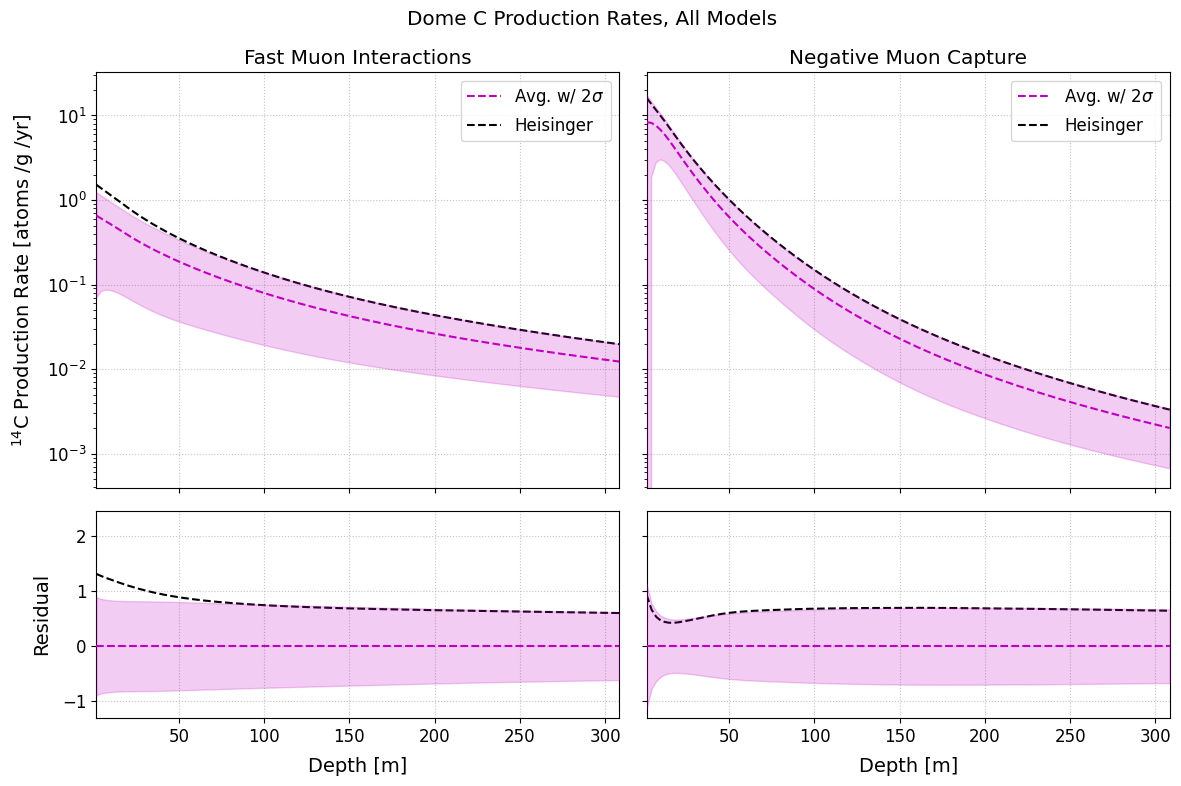

In [49]:
fig, ((ax1, ax2), (ax3,ax4)) = prod_plot(P_14C)
plt.suptitle(r'Dome C Production Rates, All Models')
plt.show()

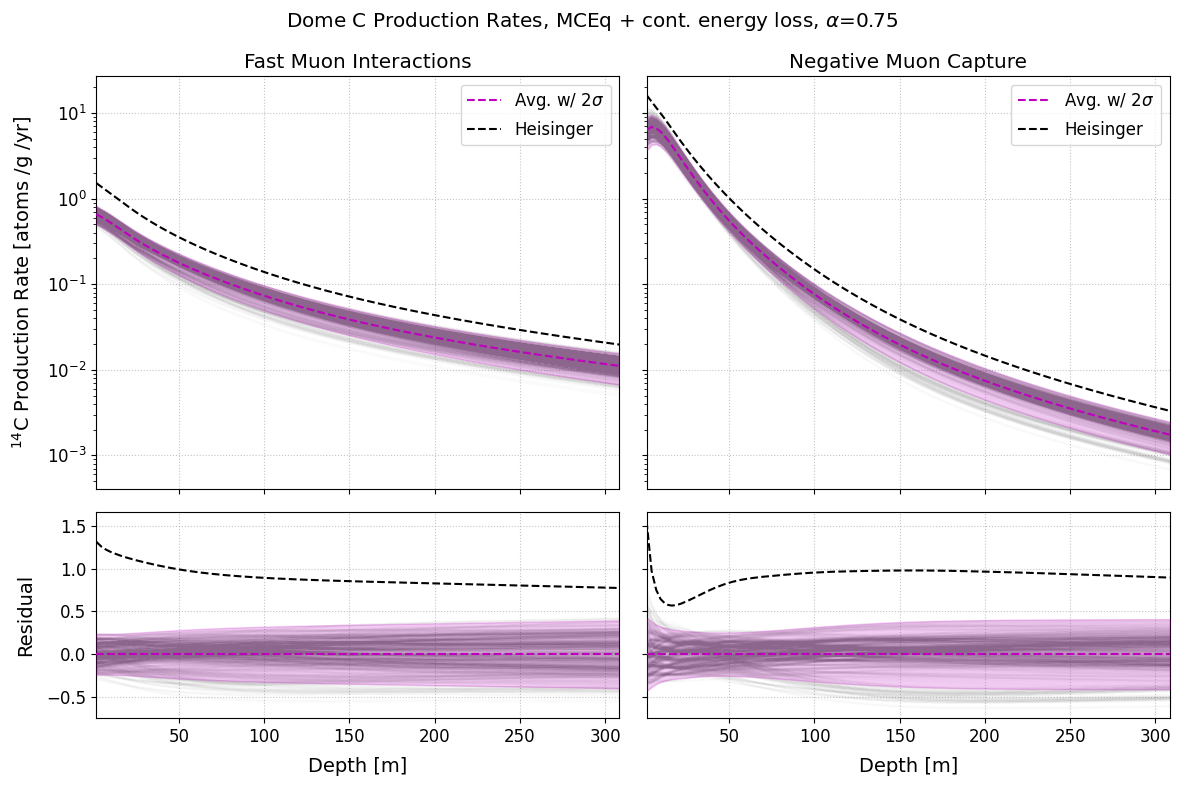

In [45]:
i = 12
fig, ((ax1, ax2), (ax3,ax4)) = prod_plot(P_14C_MCEq[i,1:].reshape(-1,2,len(Prop.z)))
plt.suptitle(r'Dome C Production Rates, MCEq + cont. energy loss, $\alpha$={:.2f}'.format(alphas[i]))
plt.show()

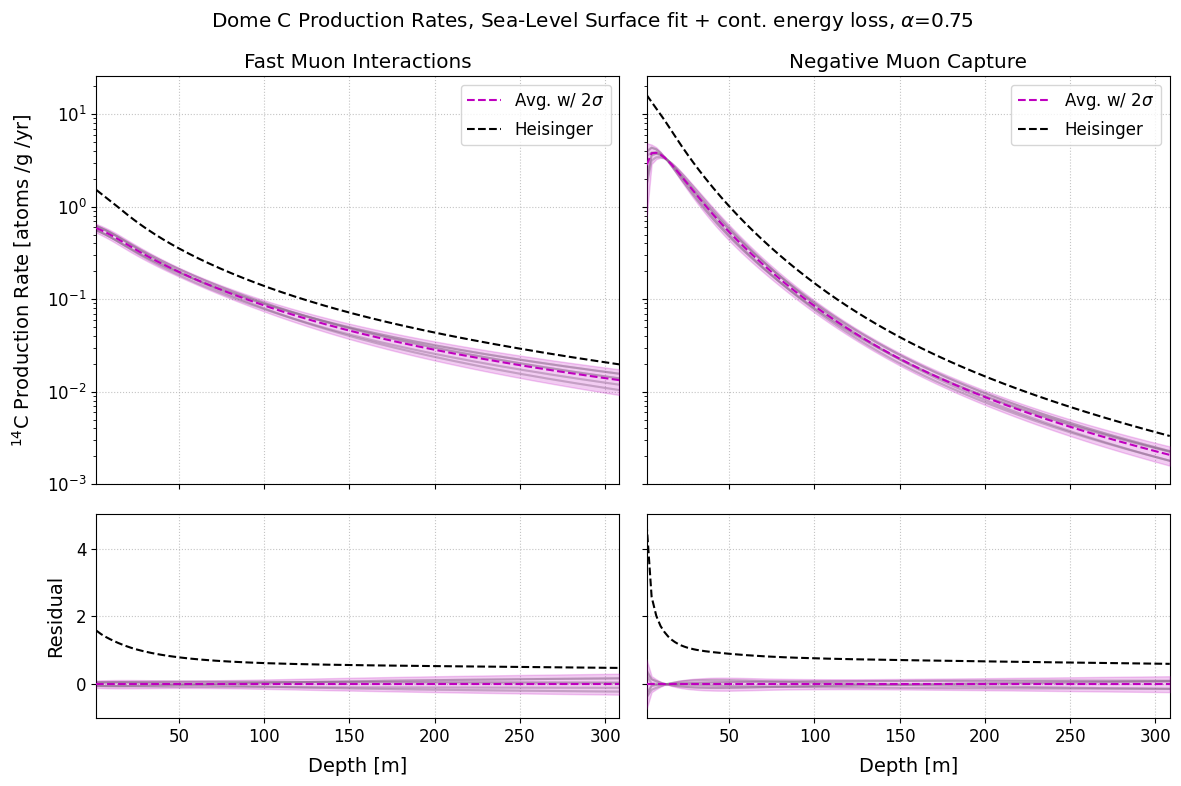

In [46]:
i = 12
fig, ((ax1, ax2), (ax3,ax4)) = prod_plot(P_14C_atmFit[i,1:].reshape(-1,2,len(Prop.z)))
plt.suptitle(r'Dome C Production Rates, Sea-Level Surface fit + cont. energy loss, $\alpha$={:.2f}'.format(alphas[i]))
plt.show()

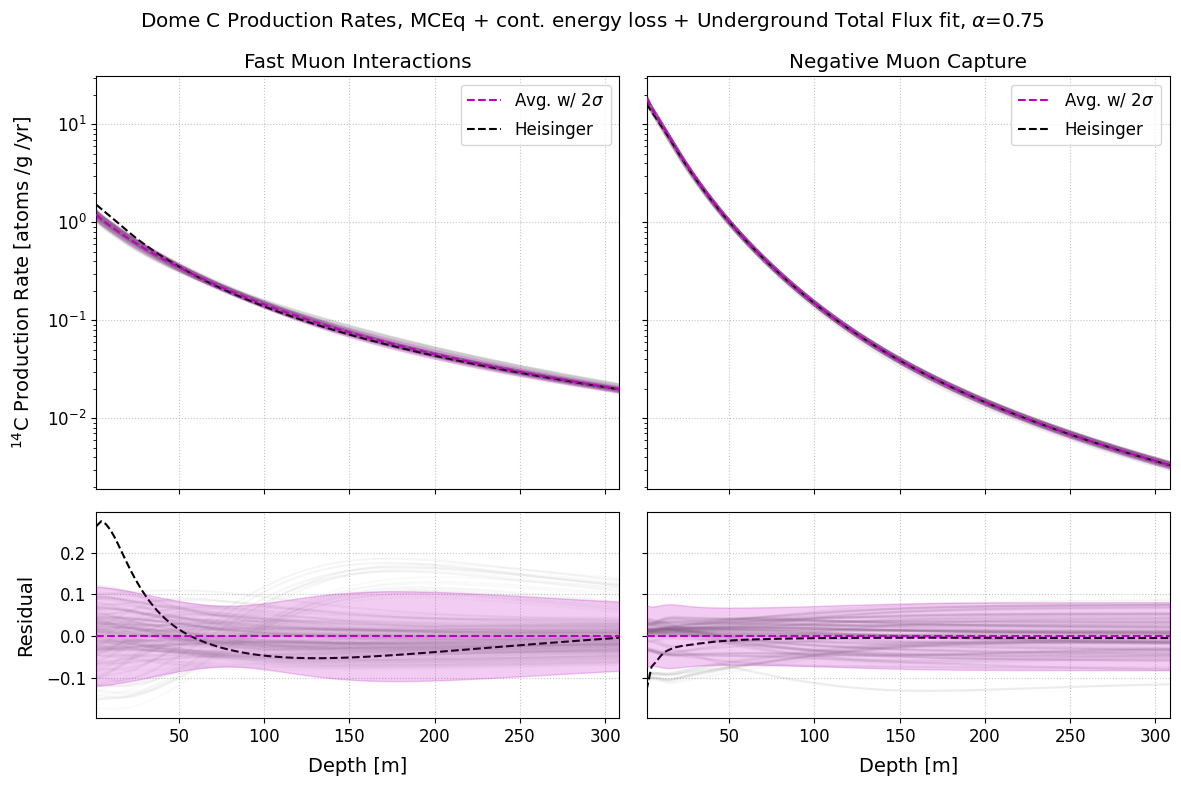

In [47]:
i = 12
fig, ((ax1, ax2), (ax3,ax4)) = prod_plot(P_14C_MCEq[i,0].reshape(-1,2,len(Prop.z)))
plt.suptitle(r'Dome C Production Rates, MCEq + cont. energy loss + Underground Total Flux fit, $\alpha$={:.2f}'.format(alphas[i]))
plt.show()

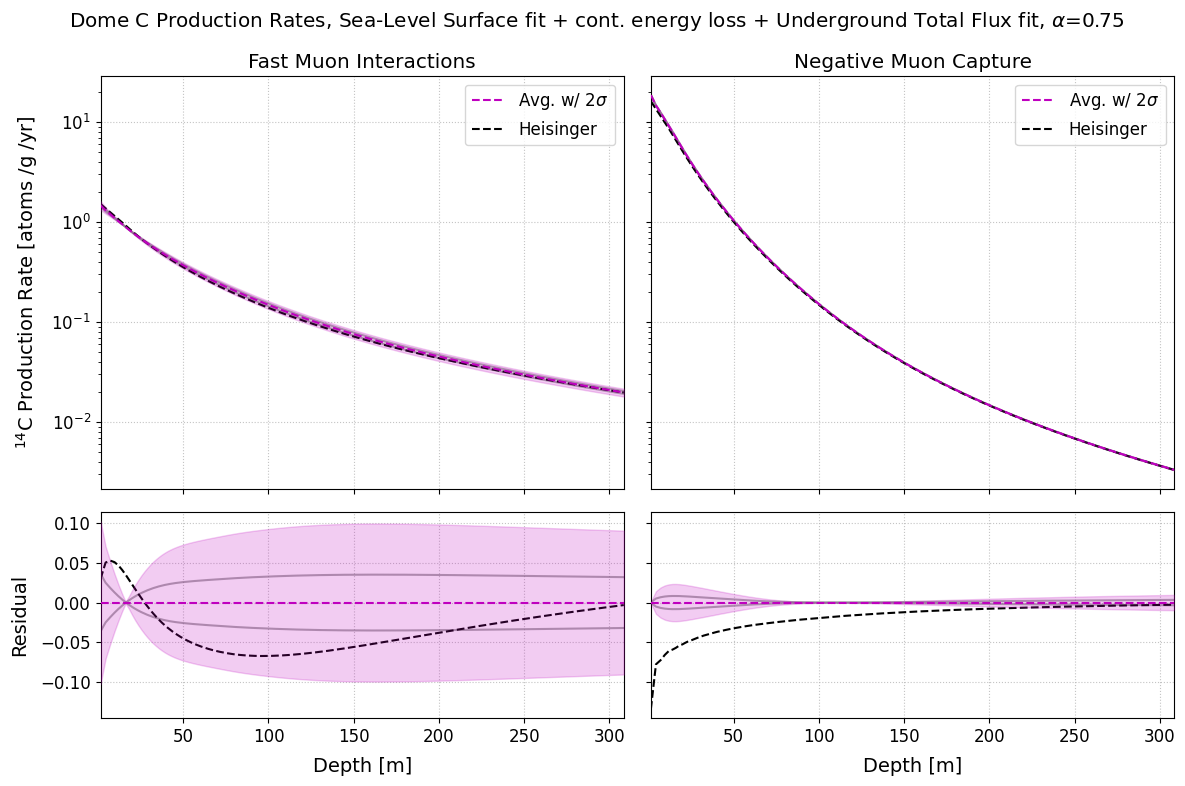

In [48]:
i = 12
fig, ((ax1, ax2), (ax3,ax4)) = prod_plot(P_14C_atmFit[i,0].reshape(-1,2,len(Prop.z)))
plt.suptitle(r'Dome C Production Rates, Sea-Level Surface fit + cont. energy loss + Underground Total Flux fit, $\alpha$={:.2f}'.format(alphas[i]))
plt.show()

$$\hat{Z} = \hat{S}\hat{H}e^{\lambda \hat{t}}$$

$\hat{H}$ - accumulation depth interpolation operator (interpolates production depths to h'(h,t))

$$H(h') = (\frac{h'-h_{i-1}}{h_i-h_{i-1}}).\text{clip}(0,1) - (\frac{h'-h_{i}}{h_{i+1}-h_{i}}).\text{clip}(0,1)$$

$h_i$ - propagation depths (for $i$<0 or $i$>max, replace the terms with $h'\geq h_0$ and $h'>h_{\text{max}}$, respectively)

$\hat{S}$ - sample operator (averages over each sample depth range in accumulation depth)

$$S(s,h) = \frac{(s^+ - h^-).\text{clip}(0,\Delta h) - (s^- - h^-).\text{clip}(0,\Delta h)}{\sum_h (s^+ - h^-).\text{clip}(0,\Delta h) - (s^- - h^-).\text{clip}(0,\Delta h)}$$

$s$ - sample depth bins (+ upper bound, - lower bound)

$h$ - accumulation depth bins (- lower bound, $\Delta$ width)

$h'(h,t) = h(t'(h)+t)$ is given by the flowpaths from Taylor Glacier

In [227]:
h = Prop.h.reshape((-1,1,1)) # production depths
x = Prop.h_prime(Prop.h_accum.reshape((1,-1,1)), Prop.t_int.reshape((1,1,-1))) # accumulation depths

h_slope = ((x-h[:-1])/np.diff(h,axis=0)).clip(0,1) # slope from 0 to 1 as x passes from lower to upper bound
H = np.concatenate([1*(x>=h[0])-h_slope[0], -np.diff(h_slope, axis=0), h_slope[-1]-1*(x>h[-1])], axis=0)
#axis0 - production depth
#axis1 - accumulation depth
#axis2 - time

In [54]:
H.shape

(255, 183, 7296)

In [55]:
Prop.S_mat.shape

(183, 10)

In [236]:
Z = np.moveaxis((H * np.exp(Prop.lambd * Prop.t_int.reshape((1,1,-1))) * Prop.dt_int.reshape((1,1,-1)))[Prop.z>Prop.z_close], 0, -1)

In [237]:
Z.shape

(183, 7296, 194)

In [239]:
Z_samp = (Z.T @ Prop.S_mat).T

In [135]:
[m.split('_')[-1] for m in models_MCEq[:,0,0,0,0]]

['alpha=0.63',
 'alpha=0.64',
 'alpha=0.65',
 'alpha=0.66',
 'alpha=0.67',
 'alpha=0.68',
 'alpha=0.69',
 'alpha=0.70',
 'alpha=0.71',
 'alpha=0.72',
 'alpha=0.73',
 'alpha=0.74',
 'alpha=0.75',
 'alpha=0.76',
 'alpha=0.77',
 'alpha=0.78',
 'alpha=0.79',
 'alpha=0.80',
 'alpha=0.81',
 'alpha=0.82',
 'alpha=0.83',
 'alpha=0.84',
 'alpha=0.85',
 'alpha=0.86',
 'alpha=0.87',
 'alpha=0.88',
 'alpha=0.89',
 'alpha=0.90',
 'alpha=0.91',
 'alpha=0.92',
 'alpha=0.93',
 'alpha=0.94',
 'alpha=0.95',
 'alpha=0.96',
 'alpha=0.97',
 'alpha=0.98',
 'alpha=0.99',
 'alpha=1.00']

In [137]:
[m.split('_')[-2] for m in models_MCEq[0,:,0,0,0]]

['H-ice',
 'GS-ice',
 'ice-None-False',
 'ice-None-True',
 'ice-Heisinger-False',
 'ice-Heisinger-True']

In [142]:
[m.split('_')[-3].split('-')[-1] for m in models_MCEq[0,0,:,0,0]]

["('MSIS00', ('SouthPole', 'January'))", "('MSIS00', ('SouthPole', 'July'))"]

In [143]:
[m.split('_')[-3].split('-')[1] for m in models_MCEq[0,0,0,:,0]]

['SIBYLL23CPP',
 'SIBYLL23C03',
 'SIBYLL',
 'SIBYLL',
 'SIBYLL',
 'EPOS',
 'QGSJET',
 'QGSJETII03',
 'QGSJET01C',
 'DPMJETIII306',
 'DPMJETIII191']

In [144]:
[m.split('_')[0] for m in models_MCEq[0,0,0,0,:]]

['GlobalSplineFitBeta',
 'HillasGaisser2012 H3a',
 'HillasGaisser2012 H4a',
 'PolyGonato',
 'GaisserStanevTilav 3-gen',
 'GaisserStanevTilav 4-gen',
 'CombinedGHandHG H3a',
 'ZatsepinSokolskaya pamela',
 'ZatsepinSokolskaya default',
 'GaisserHonda',
 'Thunman',
 'SimplePowerlaw27']

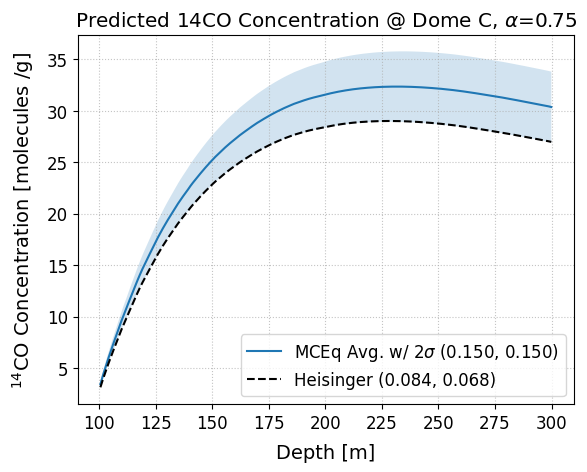

In [249]:
i=12
P_cut = P_14C_MCEq[i,1,:,1:,:3].reshape(-1,2,len(Prop.z))
P_cut_avg = np.mean(P_cut, axis=0)
P_cut_cov = np.cov(P_cut.reshape(len(P_cut),-1), rowvar=False).reshape(*P_cut.shape[1:],*P_cut.shape[1:]).swapaxes(1,2)
P_cut_std = np.sqrt([np.diag(P_cut_cov[0,0]), np.diag(P_cut_cov[1,1])])

phi = (Prop.t_int/-Prop.t_int_bins[0])*0. + 1
Z_0 = np.sum(Z, axis=1)
f = np.array([0.15,0.15])
C = (T(Z) @ phi) @ (T(P_cut_avg)[Prop.z>Prop.z_close] @ f)
C_cov = (T(Z) @ phi) @ (f @ P_cut_cov.T @ f)[Prop.z>Prop.z_close][:,Prop.z>Prop.z_close] @ (T(Z) @ phi).T
C_std = np.sqrt(np.diag(C_cov))
plt.fill_between(Prop.z_accum, C-2*C_std, C+2*C_std, alpha=0.2)
plt.plot(Prop.z_accum, C, label=r'MCEq Avg. w/ 2$\sigma$ ({:.3f}, {:.3f})'.format(*f))
#plt.plot(Prop.z_accum, (T(Z) @ phi) @ (T(P_cut_avg)[Prop.z>Prop.z_close,0]*f[0]), label=r'MCEq Avg. w/ 2$\sigma$ fast')
#plt.plot(Prop.z_accum, (T(Z) @ phi) @ (T(P_cut_avg)[Prop.z>Prop.z_close,1]*f[1]), label=r'MCEq Avg. w/ 2$\sigma$ neg')
f_H = np.array([0.084,0.068])
plt.plot(Prop.z_accum, Z_0 @ (T(P_14C[-1])[Prop.z>Prop.z_close] @ f_H), c='k', ls='--', label='Heisinger ({:.3f}, {:.3f})'.format(*f_H))

plt.xlabel('Depth [m]')
plt.ylabel(r'$^{14}$CO Concentration [molecules /g]')

plt.legend(loc='lower right')
plt.title(r'Predicted 14CO Concentration @ Dome C, $\alpha$={:.2f}'.format(alphas[i]))
plt.show()

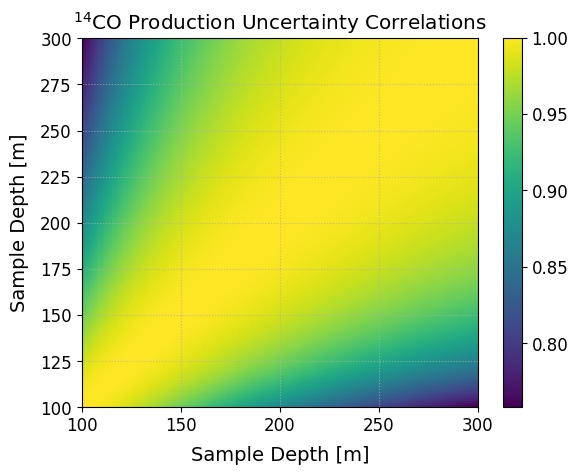

In [242]:
im = plt.imshow(C_cov/(C_std.reshape((-1,1)) * C_std.reshape((1,-1))), origin='lower', aspect='auto', interpolation='none', extent=(Prop.z_accum_bins[0], Prop.z_accum_bins[-1], Prop.z_accum_bins[0], Prop.z_accum_bins[-1]))
plt.colorbar(im)
plt.title(r'$^{14}$CO Production Uncertainty Correlations')
plt.xlabel('Sample Depth [m]')
plt.ylabel('Sample Depth [m]')
plt.show()

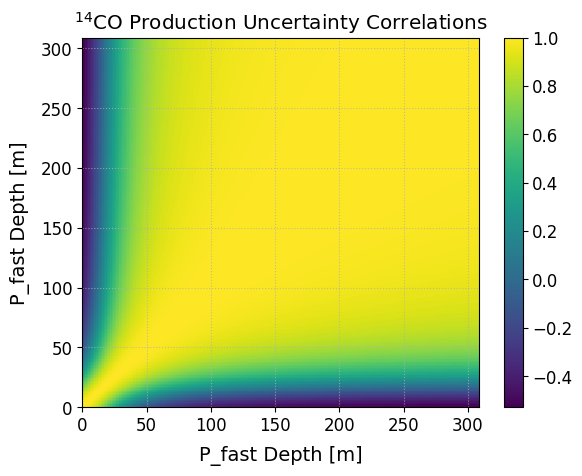

In [218]:
im = plt.imshow(P_cut_cov[0,0]/(P_cut_std[0].reshape((-1,1)) * P_cut_std[0].reshape((1,-1))), origin='lower', aspect='auto', interpolation='none', extent=(Prop.z_bins[0], Prop.z_bins[-1], Prop.z_bins[0], Prop.z_bins[-1]))
plt.colorbar(im)
plt.title(r'$^{14}$CO Production Uncertainty Correlations')
plt.xlabel('P_fast Depth [m]')
plt.ylabel('P_fast Depth [m]')
plt.show()

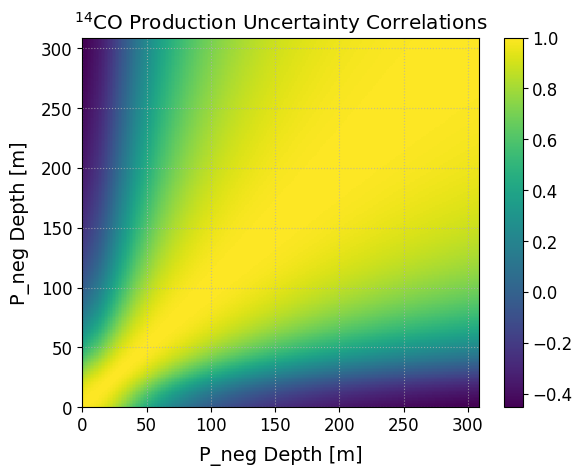

In [219]:
im = plt.imshow(P_cut_cov[1,1]/(P_cut_std[1].reshape((-1,1)) * P_cut_std[1].reshape((1,-1))), origin='lower', aspect='auto', interpolation='none', extent=(Prop.z_bins[0], Prop.z_bins[-1], Prop.z_bins[0], Prop.z_bins[-1]))
plt.colorbar(im)
plt.title(r'$^{14}$CO Production Uncertainty Correlations')
plt.xlabel('P_neg Depth [m]')
plt.ylabel('P_neg Depth [m]')
plt.show()

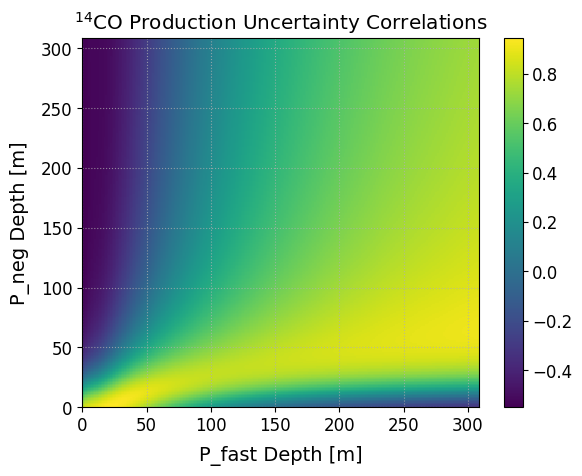

In [224]:
im = plt.imshow(P_cut_cov[0,1]/(P_cut_std[0].reshape((-1,1)) * P_cut_std[1].reshape((1,-1))), origin='lower', aspect='auto', interpolation='none', extent=(Prop.z_bins[0], Prop.z_bins[-1], Prop.z_bins[0], Prop.z_bins[-1]))
plt.colorbar(im)
plt.title(r'$^{14}$CO Production Uncertainty Correlations')
plt.xlabel('P_fast Depth [m]')
plt.ylabel('P_neg Depth [m]')
plt.show()

In [74]:
P_cov.shape

(2, 2, 255, 255)

In [65]:
Z.shape

(10, 7296, 194)